In [12]:
import femm
import matplotlib.pyplot as plt

# 1. PARAMÈTRES DE VOTRE SIMULATION

In [13]:

fichier_fem = "model_rot.fem"  # Mettez le chemin exact vers votre fichier FEMM
groupe_mobile = 1               # Le numéro du groupe de votre aimant/rotor
x_pivot = 0.0                   # Coordonnée X du centre de rotation
y_pivot = 0.0                   # Coordonnée Y du centre de rotation

angle_depart = 0
angle_fin = 60                  # On va faire tourner la pièce jusqu'à 90 degrés
pas_angle = 1                 # On fait une mesure tous les 5 degrés

# Listes pour stocker nos résultats
liste_angles = []
liste_energies = []

# 2. DÉMARRAGE DE FEMM

In [14]:
print("Démarrage de FEMM...")
femm.openfemm()
femm.opendocument(fichier_fem)

# Astuce de pro : on sauvegarde sous un nom temporaire 
# pour ne pas écraser votre fichier original avec la pièce tournée !
femm.mi_saveas("temp_simulation_rotation.fem")

Démarrage de FEMM...


# 3. LA BOUCLE DE ROTATION ET DE CALCUL

In [15]:
print("Début des calculs...")

for angle in range(angle_depart, angle_fin + 1, pas_angle):
    print(f"Calcul pour l'angle : {angle}°")
    
    # a. Lancer le calcul (les engrenages jaunes)
    femm.mi_analyze()
    
    # b. Charger les résultats (les lunettes)
    femm.mi_loadsolution()
    
    # c. Sélectionner les zones pour calculer l'énergie
    # Ici, on sélectionne tout le modèle en appelant tous les groupes utilisés (ex: 0 et 1)
    # Adaptez si vous avez mis des numéros de groupes différents pour le stator/air.
    femm.mo_groupselectblock(0) 
    femm.mo_groupselectblock(1) 
    
    # d. Calculer l'énergie magnétique stockée (Code de l'intégrale = 11 dans FEMM)
    energie_joules = femm.mo_blockintegral(2)
    
    # e. Sauvegarder les valeurs dans nos listes
    liste_angles.append(angle)
    liste_energies.append(energie_joules)
    
    # f. Fermer la fenêtre de résultats
    femm.mo_close()
    
    # g. Faire tourner la pièce pour la PROCHAINE étape de la boucle
    # On sélectionne tout le groupe, et on le fait tourner du "pas_angle"
    femm.mi_selectgroup(groupe_mobile)
    femm.mi_moverotate(x_pivot, y_pivot, pas_angle)

# On ferme FEMM proprement à la fin
print("Calculs terminés. Fermeture de FEMM.")
femm.closefemm()

Début des calculs...
Calcul pour l'angle : 0°
Calcul pour l'angle : 1°
Calcul pour l'angle : 2°
Calcul pour l'angle : 3°
Calcul pour l'angle : 4°
Calcul pour l'angle : 5°
Calcul pour l'angle : 6°
Calcul pour l'angle : 7°
Calcul pour l'angle : 8°
Calcul pour l'angle : 9°
Calcul pour l'angle : 10°
Calcul pour l'angle : 11°
Calcul pour l'angle : 12°
Calcul pour l'angle : 13°
Calcul pour l'angle : 14°
Calcul pour l'angle : 15°
Calcul pour l'angle : 16°
Calcul pour l'angle : 17°
Calcul pour l'angle : 18°
Calcul pour l'angle : 19°
Calcul pour l'angle : 20°
Calcul pour l'angle : 21°
Calcul pour l'angle : 22°
Calcul pour l'angle : 23°
Calcul pour l'angle : 24°
Calcul pour l'angle : 25°
Calcul pour l'angle : 26°
Calcul pour l'angle : 27°
Calcul pour l'angle : 28°
Calcul pour l'angle : 29°
Calcul pour l'angle : 30°
Calcul pour l'angle : 31°
Calcul pour l'angle : 32°
Calcul pour l'angle : 33°
Calcul pour l'angle : 34°
Calcul pour l'angle : 35°
Calcul pour l'angle : 36°
Calcul pour l'angle : 37°
C

In [16]:
print(liste_energies)

[23.08535450196007, 23.00069550474495, 22.89862590553884, 22.78107326392197, 22.65017873851449, 22.50973288138086, 22.36208371059802, 22.21270334820821, 22.06041017683832, 21.91165986766694, 21.76307012280337, 21.62279181097105, 21.49059552618608, 21.37136164143737, 21.26506545875722, 21.17372661321277, 21.09526002973263, 21.04088899271581, 21.00553106661742, 20.99092801489001, 20.99819884804191, 21.02411665743255, 21.07282817655842, 21.14075209639169, 21.22701324938439, 21.32925821412133, 21.44637151547038, 21.57295059548336, 21.71187474173038, 21.85457012456317, 22.00585434718222, 22.1547682450988, 22.30520479683545, 22.45214733875432, 22.59417215803344, 22.72763034662921, 22.85009061300358, 22.95802706067138, 23.04934026061058, 23.12281513525951, 23.1745828988344, 23.20303099839071, 23.20987691928598, 23.19016168336195, 23.149092644135, 23.08611237523429, 23.00001332521263, 22.89892623018966, 22.78049479003618, 22.65032217569382, 22.51021541850356, 22.36176089220765, 22.213319161652

# 4. AFFICHAGE DU GRAPHIQUE (Matplotlib)

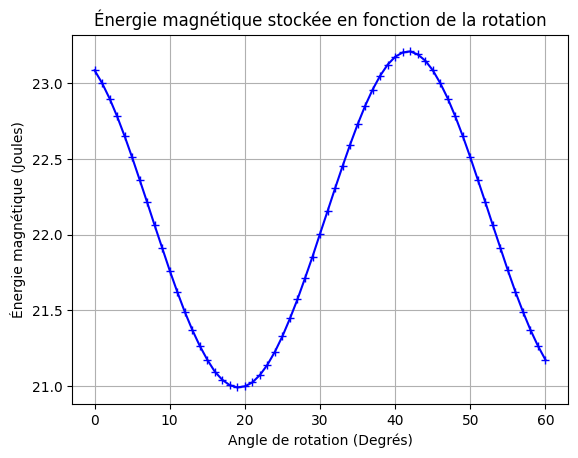

In [17]:
# On trace la courbe avec nos listes, en mettant des points (marker='o')
plt.plot(liste_angles, liste_energies, marker='+', linestyle='-', color='b')

# Personnalisation du graphique
plt.title("Énergie magnétique stockée en fonction de la rotation")
plt.xlabel("Angle de rotation (Degrés)")
plt.ylabel("Énergie magnétique (Joules)")
plt.grid(True) # Ajoute la grille en fond

# On affiche le graphique à l'écran !
plt.show()

In [18]:
#dérivée numérique pour trouver le couple électromagnétique
couple_electromagnetique = []
for i in range(1, len(liste_energies)):
    dE = liste_energies[i] - liste_energies[i-1]
    dTheta = (liste_angles[i] - liste_angles[i-1]) * (3.14159 / 180)  # Convertir en radians
    couple = dE / dTheta
    couple_electromagnetique.append(couple)

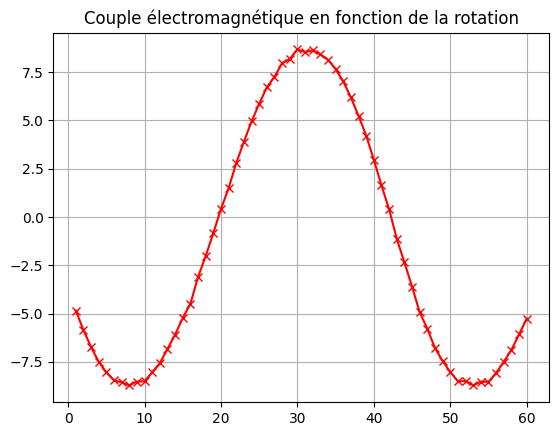

In [20]:
plt.plot(liste_angles[1:], couple_electromagnetique, marker='x', linestyle='-', color='r')
plt.title("Couple électromagnétique en fonction de la rotation")
plt.grid()